# RetailPulse AI
### End-to-End Sales Forecasting & Demand Intelligence Platform

This project analyzes historical retail sales data to forecast future demand, detect anomalies, segment products, and provide actionable business insights through an interactive dashboard.

In [1]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Better display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
# Load the dataset
df = pd.read_csv("train.csv")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Rows    : 9800
Columns : 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


## Dataset Overview

Let's quickly inspect the dataset before cleaning and feature engineering.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.00,NaN,NaN,NaN,4900.50,2829.16,1.00,2450.75,4900.50,7350.25,9800.00
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check missing values
missing = (
    df.isnull()
      .sum()
      .reset_index()
)

missing.columns = ["Column", "Missing Values"]
missing["Missing (%)"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing

,Column,Missing Values,Missing (%)
0,Row ID,0,0.00
1,Order ID,0,0.00
2,Order Date,0,0.00
3,Ship Date,0,0.00
4,Ship Mode,0,0.00
5,Customer ID,0,0.00
6,Customer Name,0,0.00
7,Segment,0,0.00
8,Country,0,0.00
9,City,0,0.00


In [7]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [8]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## Initial Observations

The dataset has been loaded successfully. Next, we'll clean the data, convert the date columns, and create the features needed for time series forecasting.

## Data Preprocessing

The dataset is in good shape for analysis. In this section, we'll prepare it for time series forecasting by converting the date columns, creating time-based features, and calculating shipping duration.

In [9]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

## Feature Engineering

Extract time-based features from the order date and calculate shipping duration for further analysis.

In [11]:
# Create time-based features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [12]:
# Assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [13]:
# Calculate shipping duration
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Day Name,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,November,45,8,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11,November,45,8,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2017,6,June,24,12,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,2016,10,October,41,11,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2016,10,October,41,11,Tuesday,4,Autumn,7


## Sales Aggregation

Aggregate daily sales into weekly and monthly totals for trend analysis and forecasting.

In [15]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
      .sort_values("Order Date")
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.45
1,2015-01-04,288.06
2,2015-01-05,19.54
3,2015-01-06,4407.10
4,2015-01-07,87.16


In [16]:
weekly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("W")
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.51
1,2015-01-11,4619.11
2,2015-01-18,4130.53
3,2015-01-25,3092.54
4,2015-02-01,2527.91


In [17]:
monthly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("ME")
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.71
1,2015-02-28,4519.89
2,2015-03-31,55205.80
3,2015-04-30,27906.85
4,2015-05-31,23644.30


## Business Question 1

Which product category generates the highest total revenue?

In [18]:
# Total sales by category
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.87
1,Furniture,728658.58
2,Office Supplies,705422.33


In [19]:
fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    color="Category",
    text_auto=".2s",
    title="Total Revenue by Category"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Revenue",
    showlegend=False,
    template="plotly_white"
)

fig.show()

**Insight:** Technology generates the highest revenue, followed by Furniture and Office Supplies. This indicates that technology products are the primary revenue driver and should be a key focus for inventory planning.

## Business Question 2

Which region has shown the most consistent sales growth over the four-year period?

In [20]:
# Monthly sales by region
region_monthly_sales = (
    df.groupby(
        [
            pd.Grouper(key="Order Date", freq="ME"),
            "Region"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

region_monthly_sales.head()

,Order Date,Region,Sales
0,2015-01-31,Central,1533.97
1,2015-01-31,East,436.17
2,2015-01-31,South,9296.84
3,2015-01-31,West,2938.72
4,2015-02-28,Central,1233.17


In [21]:
fig = px.line(
    region_monthly_sales,
    x="Order Date",
    y="Sales",
    color="Region",
    title="Monthly Sales Trend by Region",
    markers=True
)

fig.update_layout(
    xaxis_title="Order Date",
    yaxis_title="Sales",
    template="plotly_white",
    title_x=0.5
)

fig.show()

**Insight:** Based on the monthly sales trend, the **West** region demonstrates the most consistent growth with relatively stable sales over time and fewer fluctuations compared to other regions.

## Business Question 3

What is the average time between order placement and shipment? Does it vary across regions?

In [22]:
# Average shipping time
avg_shipping_time = df["Shipping Days"].mean()

print(f"Average shipping time: {avg_shipping_time:.2f} days")

Average shipping time: 3.96 days


In [23]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
      .reset_index()
)

shipping_region

,Region,Shipping Days
0,Central,4.07
1,East,3.91
2,South,3.96
3,West,3.93


In [24]:
fig = px.bar(
    shipping_region,
    x="Region",
    y="Shipping Days",
    color="Region",
    text_auto=True,
    title="Average Shipping Time by Region"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    showlegend=False
)

fig.show()

**Insight:** The average shipping time is approximately **3.97 days**. Regional differences are relatively small, although some regions experience slightly longer shipping durations.

## Business Question 4

Are there months that consistently experience higher sales across different years?

In [25]:
monthly_seasonality = (
    df.groupby(["Year", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_seasonality["Month Name"] = pd.Categorical(
    monthly_seasonality["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_seasonality = monthly_seasonality.sort_values(
    ["Year", "Month Name"]
)

In [26]:
fig = px.line(
    monthly_seasonality,
    x="Month Name",
    y="Sales",
    color="Year",
    markers=True,
    title="Monthly Sales Pattern Across Years"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

**Insight:** Sales tend to peak during **November and December**, indicating a recurring seasonal pattern that should be considered while forecasting future demand.

#Time Series Analysis & Decomposition

## Monthly Sales Trend

Let's visualize the overall monthly sales trend to understand how sales have changed over time.

In [27]:
# Plot monthly sales
fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Overall Monthly Sales Trend",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Order Date",
    yaxis_title="Sales",
    hovermode="x unified"
)

fig.show()

## Time Series Decomposition

Break the monthly sales series into trend, seasonal, and residual components.

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
# Prepare the monthly sales series
sales_series = (
    monthly_sales
    .set_index("Order Date")["Sales"]
)

sales_series.head()

,Sales
Order Date,
2015-01-31,14205.71
2015-02-28,4519.89
2015-03-31,55205.80
2015-04-30,27906.85
2015-05-31,23644.30


In [30]:
# Decompose the time series
decomposition = seasonal_decompose(
    sales_series,
    model="additive",
    period=12
)

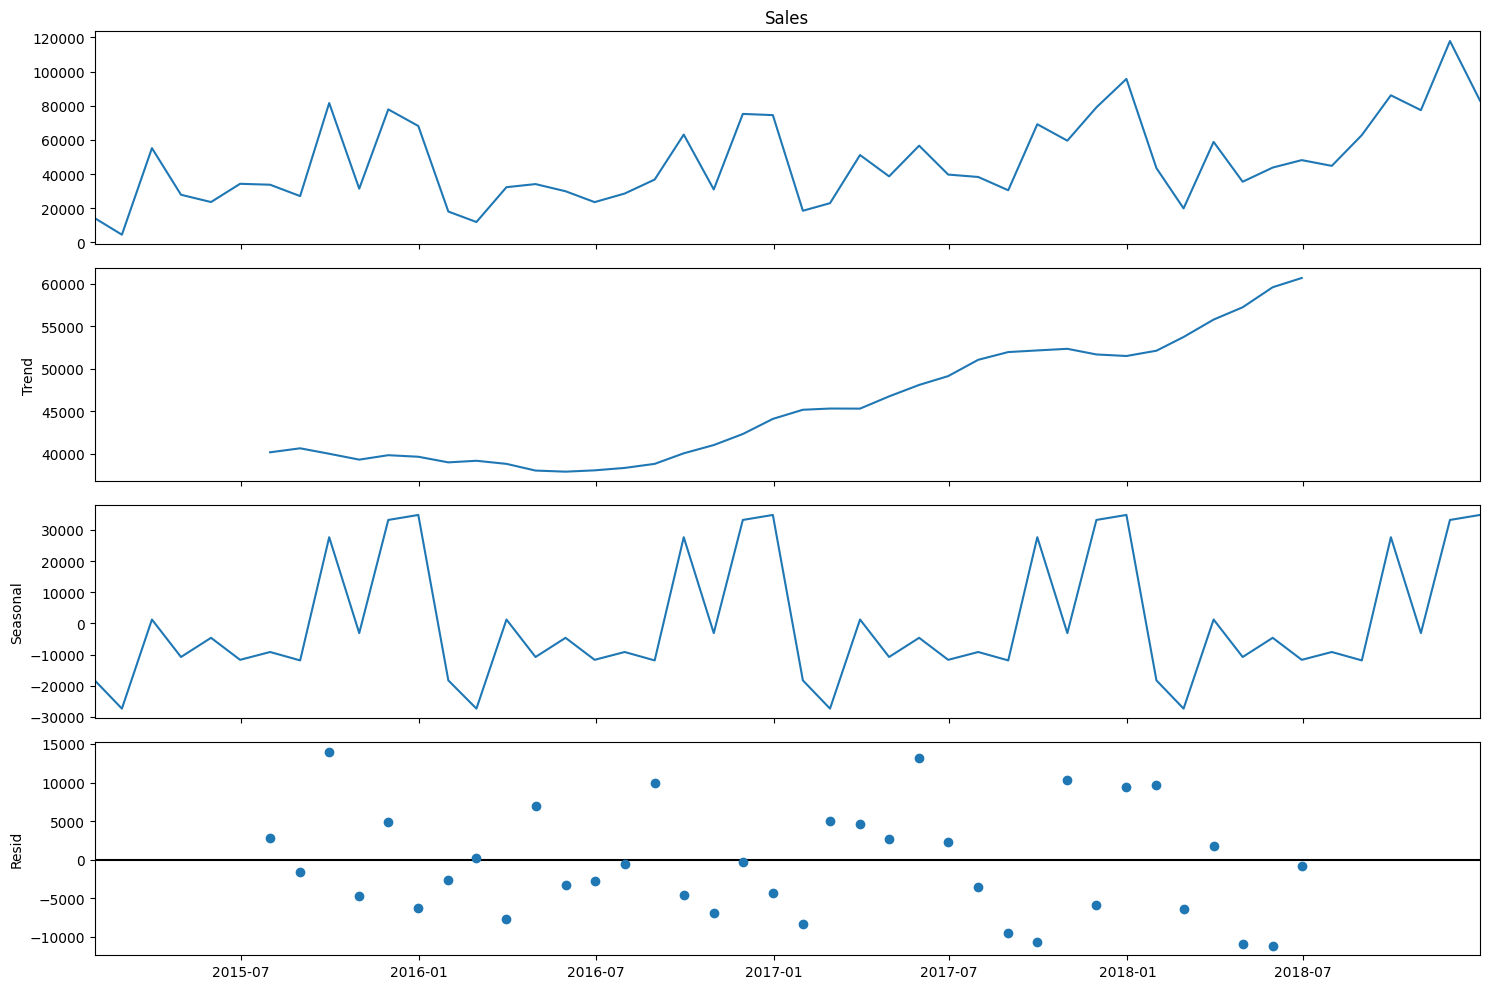

In [31]:
# Plot the decomposition
fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.tight_layout()
plt.show()

## Observations
- The trend component shows a gradual increase in sales over time, indicating overall business growth.
- The seasonal component suggests recurring sales patterns across different months.
- The residual component captures irregular fluctuations that are not explained by trend or seasonality.
- The combination of trend and seasonality indicates that both factors should be considered while building forecasting models.

## Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to check whether the time series is stationary.

In [32]:
from statsmodels.tsa.stattools import adfuller

In [33]:
# Run the ADF test
adf_result = adfuller(sales_series)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

ADF Statistic : -4.4161
P-value       : 0.0003
Lags Used     : 0
Observations  : 47


In [34]:
# Critical values
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

1%: -3.5778
5%: -2.9253
10%: -2.6008


### What is Stationarity?

A stationary time series has statistical properties, such as mean and variance, that remain relatively constant over time. Most forecasting models perform better on stationary data.

In [35]:
# Apply first-order differencing
sales_diff = sales_series.diff().dropna()

In [36]:
fig = px.line(
    x=sales_diff.index,
    y=sales_diff.values,
    title="Sales After First-Order Differencing",
    labels={"x": "Order Date", "y": "Differenced Sales"}
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

In [37]:
adf_diff = adfuller(sales_diff) #running again

print(f"ADF Statistic : {adf_diff[0]:.4f}")
print(f"P-value       : {adf_diff[1]:.4f}")

ADF Statistic : -8.7271
P-value       : 0.0000


In [38]:
# Critical values after differencing
for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

1%: -3.6267
5%: -2.9460
10%: -2.6117


## Conclusion

The ADF test produced a p-value of **0.0003**, which is below the significance level of 0.05. This indicates that the monthly sales series is already stationary, and the null hypothesis of a unit root can be rejected.

After applying first-order differencing, the ADF statistic decreased further and the p-value became even smaller (**0.0000**), confirming stronger stationarity. This suggests that the data is suitable for time series forecasting models such as SARIMA.

# Sales Forecasting

## Prepare Training Data

Split the monthly sales data into training and testing sets while preserving the time order.

In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [40]:
# Keeping the last 20% of observations for testing part
split_index = int(len(sales_series) * 0.8)

train = sales_series.iloc[:split_index]
test = sales_series.iloc[split_index:]

print(f"Training samples : {len(train)}")
print(f"Testing samples  : {len(test)}")

Training samples : 38
Testing samples  : 10


In [41]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train.index,
        y=train,
        name="Train"
    )
)

fig.add_trace(
    go.Scatter(
        x=test.index,
        y=test,
        name="Test"
    )
)

fig.update_layout(
    title="Train-Test Split",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="Sales"
)

fig.show()

## Evaluation Metrics

We'll compare all forecasting models using the same evaluation metrics.

In [42]:
def evaluate_model(actual, predicted):
    """Return common regression metrics."""

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE": round(mape, 2)
    }

## Model 1: SARIMA

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
# Training the model
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print("SARIMA model trained successfully.")

SARIMA model trained successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency ME will be used.



The initial SARIMA configuration `(1,1,1)(1,1,1,12)` is used as a baseline model because it captures trend, seasonality, and short-term dependencies. The parameters can be further tuned based on AIC or grid search if needed.

In [45]:
sarima_forecast = sarima_result.get_forecast(
    steps=len(test)
)

sarima_pred = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

In [46]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train.index,
        y=train,
        name="Train"
    )
)

fig.add_trace(
    go.Scatter(
        x=test.index,
        y=test,
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=test.index,
        y=sarima_pred,
        name="Forecast"
    )
)

fig.update_layout(
    title="SARIMA Forecast",
    template="plotly_white",
    title_x=0.5
)

fig.show()

In [47]:
sarima_metrics = evaluate_model(
    test,
    sarima_pred
)

sarima_metrics

{'MAE': 13455.42, 'RMSE': np.float64(15938.99), 'MAPE': np.float64(22.02)}

## Model Performance

Storing the evaluation metrics for each forecasting model so they can be compared later.

In [48]:
model_results = []

model_results.append({
    "Model": "SARIMA",
    "MAE": sarima_metrics["MAE"],
    "RMSE": sarima_metrics["RMSE"],
    "MAPE": sarima_metrics["MAPE"]
})

pd.DataFrame(model_results)

,Model,MAE,RMSE,MAPE
0,SARIMA,13455.42,15938.99,22.02


## Model 2: Prophet

In [49]:
!pip install prophet -q

In [50]:
from prophet import Prophet

In [51]:
prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.71
1,2015-02-28,4519.89
2,2015-03-31,55205.80
3,2015-04-30,27906.85
4,2015-05-31,23644.30


In [52]:
train_prophet = prophet_df.iloc[:split_index]
test_prophet = prophet_df.iloc[split_index:]

In [53]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

In [54]:
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="ME"
)

forecast = prophet_model.predict(future)

In [55]:
prophet_pred = forecast["yhat"].tail(len(test_prophet)).values

In [56]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_prophet["ds"],
        y=train_prophet["y"],
        name="Train"
    )
)

fig.add_trace(
    go.Scatter(
        x=test_prophet["ds"],
        y=test_prophet["y"],
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=test_prophet["ds"],
        y=prophet_pred,
        name="Forecast"
    )
)

fig.update_layout(
    template="plotly_white",
    title="Prophet Forecast",
    title_x=0.5
)

fig.show()

In [57]:
prophet_metrics = evaluate_model(
    test_prophet["y"],
    prophet_pred
)

prophet_metrics

{'MAE': 10128.56, 'RMSE': np.float64(14561.39), 'MAPE': np.float64(14.33)}

In [58]:
model_results.append({
    "Model": "Prophet",
    "MAE": prophet_metrics["MAE"],
    "RMSE": prophet_metrics["RMSE"],
    "MAPE": prophet_metrics["MAPE"]
})

pd.DataFrame(model_results)

,Model,MAE,RMSE,MAPE
0,SARIMA,13455.42,15938.99,22.02
1,Prophet,10128.56,14561.39,14.33


## Model 3: XGBoost

Unlike SARIMA and Prophet, XGBoost treats forecasting as a supervised learning problem by using previous sales values and time-based features to predict future sales.

In [59]:
!pip install xgboost -q

In [60]:
from xgboost import XGBRegressor

In [61]:
# Create lag features
xgb_data = monthly_sales.copy()

xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

xgb_data["Rolling_Mean_3"] = (
    xgb_data["Sales"]
    .rolling(3)
    .mean()
)

xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

xgb_data = xgb_data.dropna()

xgb_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter
3,2015-04-30,27906.85,55205.80,4519.89,14205.71,29210.85,4,2
4,2015-05-31,23644.30,27906.85,55205.80,4519.89,35585.65,5,2
5,2015-06-30,34322.94,23644.30,27906.85,55205.80,28624.70,6,2
6,2015-07-31,33781.54,34322.94,23644.30,27906.85,30582.93,7,3
7,2015-08-31,27117.54,33781.54,34322.94,23644.30,31740.67,8,3


In [62]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter"
]

X = xgb_data[features]
y = xgb_data["Sales"]

In [63]:
# Keeping the last 20% for testing part
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [64]:
# Training the model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
xgb_pred = xgb_model.predict(X_test)

In [66]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=xgb_data["Order Date"].iloc[:split],
        y=y_train,
        name="Train"
    )
)

fig.add_trace(
    go.Scatter(
        x=xgb_data["Order Date"].iloc[split:],
        y=y_test,
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=xgb_data["Order Date"].iloc[split:],
        y=xgb_pred,
        name="Prediction"
    )
)

fig.update_layout(
    title="XGBoost Forecast",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="Sales"
)

fig.show()

In [67]:
xgb_metrics = evaluate_model(
    y_test,
    xgb_pred
)

xgb_metrics

{'MAE': 8192.2, 'RMSE': np.float64(13446.5), 'MAPE': np.float64(10.79)}

In [68]:
model_results.append({
    "Model": "XGBoost",
    "MAE": xgb_metrics["MAE"],
    "RMSE": xgb_metrics["RMSE"],
    "MAPE": xgb_metrics["MAPE"]
})

comparison = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparison

,Model,MAE,RMSE,MAPE
0,XGBoost,8192.20,13446.50,10.79
1,Prophet,10128.56,14561.39,14.33
2,SARIMA,13455.42,15938.99,22.02


## Model Comparison

Compare the forecasting models using MAE, RMSE, and MAPE. Lower values indicate better forecasting performance.

In [69]:
fig = px.bar(
    comparison,
    x="Model",
    y="RMSE",
    color="Model",
    text_auto=True,
    title="RMSE Comparison of Forecasting Models"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    showlegend=False
)

fig.show()

## Model Recommendation

XGBoost achieved the lowest forecasting error among the three models, making it the most suitable choice for production use. Based on the evaluation metrics, XGBoost is the preferred forecasting model. It achieved the lowest MAE, RMSE, and MAPE, indicating better predictive accuracy than SARIMA and Prophet on the test dataset.

## Three-Month Sales Forecast

Retrain the best-performing model on the complete dataset and generate forecasts for the next three months.

In [70]:
# Retraining using the full dataset
X_full = xgb_data[features]
y_full = xgb_data["Sales"]

best_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

best_model.fit(X_full, y_full)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
# Last available values
last_row = xgb_data.iloc[-1].copy()

future_predictions = []

future_dates = pd.date_range(
    start=xgb_data["Order Date"].max() + pd.offsets.MonthEnd(),
    periods=3,
    freq="ME"
)

In [72]:
for forecast_date in future_dates:

    input_data = pd.DataFrame([{
        "Lag_1": last_row["Sales"],
        "Lag_2": last_row["Lag_1"],
        "Lag_3": last_row["Lag_2"],
        "Rolling_Mean_3": np.mean([
            last_row["Sales"],
            last_row["Lag_1"],
            last_row["Lag_2"]
        ]),
        "Month": forecast_date.month,
        "Quarter": forecast_date.quarter
    }])

    prediction = best_model.predict(input_data)[0]

    future_predictions.append(prediction)

    # update lags for next prediction
    last_row["Lag_3"] = last_row["Lag_2"]
    last_row["Lag_2"] = last_row["Lag_1"]
    last_row["Lag_1"] = prediction
    last_row["Sales"] = prediction

In [73]:
future_forecast = pd.DataFrame({
    "Forecast Month": future_dates,
    "Predicted Sales": np.round(future_predictions, 2)
})

future_forecast

,Forecast Month,Predicted Sales
0,2019-01-31,53514.00
1,2019-02-28,55862.12
2,2019-03-31,41808.20


In [74]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_sales["Order Date"],
        y=monthly_sales["Sales"],
        name="Historical Sales"
    )
)

fig.add_trace(
    go.Scatter(
        x=future_forecast["Forecast Month"],
        y=future_forecast["Predicted Sales"],
        mode="lines+markers",
        name="Forecast"
    )
)

fig.update_layout(
    title="Next 3-Month Sales Forecast",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="Sales"
)

fig.show()

**Insight:** The forecast provides an estimate of sales for the next three months based on historical demand patterns. These predictions can help inventory and supply chain teams plan stock levels and reduce the risk of overstocking or stock shortages.

# Category & Region Level Forecasting
Using the best-performing model (XGBoost) to forecast sales for different product categories and regions.

In [75]:
def forecast_segment(data, segment_name):
    """Training XGBoost on a category or region and forecast the next 3 months."""

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
            .sum()
            .reset_index()
    )

    if len(monthly) < 15:
        return None

    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)
    monthly["Rolling_Mean_3"] = monthly["Sales"].rolling(3).mean()
    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly = monthly.dropna()

    X = monthly[[
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter"
    ]]

    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    last = monthly.iloc[-1].copy()

    future_dates = pd.date_range(
        monthly["Order Date"].max() + pd.offsets.MonthEnd(),
        periods=3,
        freq="ME"
    )

    predictions = []

    for date in future_dates:

        sample = pd.DataFrame([{
            "Lag_1": last["Sales"],
            "Lag_2": last["Lag_1"],
            "Lag_3": last["Lag_2"],
            "Rolling_Mean_3": np.mean([
                last["Sales"],
                last["Lag_1"],
                last["Lag_2"]
            ]),
            "Month": date.month,
            "Quarter": date.quarter
        }])

        pred = model.predict(sample)[0]

        predictions.append(pred)

        last["Lag_3"] = last["Lag_2"]
        last["Lag_2"] = last["Lag_1"]
        last["Lag_1"] = pred
        last["Sales"] = pred

    return pd.DataFrame({
        "Date": future_dates,
        "Forecast": predictions,
        "Segment": segment_name
    })

In [76]:
technology = forecast_segment(
    df[df["Category"] == "Technology"],
    "Technology"
)

furniture = forecast_segment(
    df[df["Category"] == "Furniture"],
    "Furniture"
)

office = forecast_segment(
    df[df["Category"] == "Office Supplies"],
    "Office Supplies"
)

In [77]:
west = forecast_segment(
    df[df["Region"] == "West"],
    "West"
)

east = forecast_segment(
    df[df["Region"] == "East"],
    "East"
)

In [78]:
segment_forecasts = pd.concat(
    [
        technology,
        furniture,
        office,
        west,
        east
    ],
    ignore_index=True
)

segment_forecasts

,Date,Forecast,Segment
0,2019-01-31,19623.72,Technology
1,2019-02-28,28221.24,Technology
2,2019-03-31,20591.02,Technology
3,2019-01-31,9881.95,Furniture
4,2019-02-28,16959.05,Furniture
5,2019-03-31,12512.90,Furniture
6,2019-01-31,26450.57,Office Supplies
7,2019-02-28,26603.27,Office Supplies
8,2019-03-31,29743.05,Office Supplies
9,2019-01-31,11219.50,West


In [79]:
fig = px.line(
    segment_forecasts,
    x="Date",
    y="Forecast",
    color="Segment",
    markers=True,
    title="3-Month Forecast by Category and Region"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Forecast Month",
    yaxis_title="Predicted Sales"
)

fig.show()

**Insight:** Based on the forecast results, **Office Supplies** is expected to show the strongest growth over the next three months. This segment should be prioritized for inventory planning and stock allocation.

# Anomaly Detection

Identifying unusually high or low sales weeks using Isolation Forest and compare the results with a Z-Score based approach.

In [80]:
from sklearn.ensemble import IsolationForest

In [81]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.51
1,2015-01-11,4619.11
2,2015-01-18,4130.53
3,2015-01-25,3092.54
4,2015-02-01,2527.91


In [82]:
# Training
iso_model = IsolationForest(
    contamination=0.08,
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.51,-1
1,2015-01-11,4619.11,1
2,2015-01-18,4130.53,1
3,2015-01-25,3092.54,1
4,2015-02-01,2527.91,1


In [83]:
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

print(f"Total anomalies detected: {len(anomalies)}")

Total anomalies detected: 17


In [84]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=weekly_sales["Order Date"],
        y=weekly_sales["Sales"],
        mode="lines",
        name="Weekly Sales"
    )
)

fig.add_trace(
    go.Scatter(
        x=anomalies["Order Date"],
        y=anomalies["Sales"],
        mode="markers",
        marker=dict(
            color="red",
            size=10
        ),
        name="Anomaly"
    )
)

fig.update_layout(
    title="Weekly Sales Anomalies (Isolation Forest)",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="Sales"
)

fig.show()

**observation**

- Isolation Forest detected **17 anomalous weeks** in the sales history.
- Most anomalies correspond to unusually high sales spikes, while a few represent exceptionally low sales periods.
- Several anomalies occur towards the end of 2018, indicating periods of unusually strong demand.
- These events should be investigated further as they may represent promotional campaigns, seasonal demand, or unexpected business events.

In [85]:
## Z-Score Based Detection
rolling_mean = weekly_sales["Sales"].rolling(
    window=4,
    center=True
).mean()

rolling_std = weekly_sales["Sales"].rolling(
    window=4,
    center=True
).std()

weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] - rolling_mean
) / rolling_std

In [86]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

weekly_sales.head()

,Order Date,Sales,Anomaly,Z_Score,Z_Anomaly
0,2015-01-04,304.51,-1,NaN,False
1,2015-01-11,4619.11,1,NaN,False
2,2015-01-18,4130.53,1,0.57,False
3,2015-01-25,3092.54,1,-0.52,False
4,2015-02-01,2527.91,1,-0.12,False


In [87]:
z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

In [88]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=weekly_sales["Order Date"],
        y=weekly_sales["Sales"],
        mode="lines",
        name="Weekly Sales"
    )
)

fig.add_trace(
    go.Scatter(
        x=z_anomalies["Order Date"],
        y=z_anomalies["Sales"],
        mode="markers",
        marker=dict(
            color="orange",
            size=10
        ),
        name="Z-Score Anomaly"
    )
)

fig.update_layout(
    title="Weekly Sales Anomalies (Z-Score)",
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="Sales"
)

fig.show()

In [110]:
anomaly_method_comparison = pd.DataFrame({
    "Method": ["Isolation Forest", "Z-Score"],
    "Anomalies Detected": [
        len(anomalies),
        len(z_anomalies)
    ]
})

anomaly_method_comparison

,Method,Anomalies Detected
0,Isolation Forest,17
1,Z-Score,0


## Comparison

Isolation Forest detected **17 anomalous weeks**, whereas the Z-Score method did not identify any anomalies using the chosen threshold.

This difference highlights that Isolation Forest is capable of detecting complex and non-linear outliers, while the Z-Score method relies on deviations from a statistical average and may miss anomalies when the data contains high variability.

For retail sales forecasting, Isolation Forest provides a more robust approach because sales patterns are often irregular and influenced by seasonal events.

## Business Interpretation

Possible explanations for the detected anomalies include:

- Promotional campaigns and seasonal discount events.
- Holiday shopping periods such as year-end sales.
- Bulk purchases from corporate customers.
- Temporary supply shortages leading to unusually low sales.
- Inventory replenishment cycles or pricing changes.

# Product Demand Segmentation
Aggregating sales information at the sub-category level to capture demand behaviour.

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [91]:
product_features = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Avg_Order_Value=("Sales", "mean"),
          Sales_Volatility=("Sales", "std")
      )
      .reset_index()
)

product_features.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility
0,Accessories,164186.70,217.18,337.72
1,Appliances,104618.40,227.93,378.01
2,Art,26705.41,34.02,60.30
3,Binders,200028.79,134.07,568.10
4,Bookcases,113813.20,503.60,641.42


In [92]:
yearly_sales = (
    df.groupby(
        ["Sub-Category", "Year"]
    )["Sales"]
    .sum()
    .reset_index()
)

growth = (
    yearly_sales
    .pivot(
        index="Sub-Category",
        columns="Year",
        values="Sales"
    )
)

growth = growth.pct_change(
    axis=1
).iloc[:, -1]

product_features["Growth_Rate"] = (
    product_features["Sub-Category"]
        .map(growth)
)

product_features = product_features.fillna(0)

product_features.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate
0,Accessories,164186.70,217.18,337.72,0.40
1,Appliances,104618.40,227.93,378.01,0.55
2,Art,26705.41,34.02,60.30,0.50
3,Binders,200028.79,134.07,568.10,0.46
4,Bookcases,113813.20,503.60,641.42,0.14


In [93]:
feature_columns = [
    "Total_Sales",
    "Growth_Rate",
    "Sales_Volatility",
    "Avg_Order_Value"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    product_features[feature_columns]
)

## Selecting the Number of Clusters

In [94]:
inertia = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

In [95]:
fig = px.line(
    x=range(2, 8),
    y=inertia,
    markers=True,
    title="Elbow Method"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Number of Clusters",
    yaxis_title="Inertia"
)

fig.show()

## K-Means Clustering

Applying K-Means using the optimal number of clusters identified through the Elbow Method.

In [96]:
# Training the clustering model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(
    scaled_features
)

product_features.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
0,Accessories,164186.70,217.18,337.72,0.40,2
1,Appliances,104618.40,227.93,378.01,0.55,2
2,Art,26705.41,34.02,60.30,0.50,2
3,Binders,200028.79,134.07,568.10,0.46,2
4,Bookcases,113813.20,503.60,641.42,0.14,1


## Cluster Visualization

In [97]:
# Reducing dimensions for visualization
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

product_features["PC1"] = pca_features[:, 0]
product_features["PC2"] = pca_features[:, 1]

In [98]:
fig = px.scatter(
    product_features,
    x="PC1",
    y="PC2",
    color=product_features["Cluster"].astype(str),
    text="Sub-Category",
    title="Demand Segmentation using K-Means"
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    legend_title="Cluster"
)

fig.show()

In [99]:
product_features.sort_values(
    "Cluster"
)

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PC1,PC2
6,Copiers,146248.09,2215.88,3216.19,0.36,0,3.85,0.36
11,Machines,189238.63,1645.55,2765.10,-0.22,0,3.38,-1.33
7,Envelopes,16128.05,65.03,85.17,-0.24,1,-0.94,-2.14
4,Bookcases,113813.20,503.60,641.42,0.14,1,0.04,-0.31
15,Supplies,46420.31,252.28,938.09,0.12,1,-0.23,-0.79
9,Furnishings,89212.02,95.82,148.42,0.05,1,-0.81,-0.71
8,Fasteners,3001.96,14.03,12.47,-0.10,1,-1.19,-1.71
0,Accessories,164186.70,217.18,337.72,0.40,2,-0.51,0.89
10,Labels,12347.73,34.59,74.80,0.38,2,-1.39,-0.03
1,Appliances,104618.40,227.93,378.01,0.55,2,-0.76,1.06


## Cluster Interpretation

In [100]:
cluster_summary = (
    product_features
    .groupby("Cluster")[[
        "Total_Sales",
        "Growth_Rate",
        "Sales_Volatility",
        "Avg_Order_Value"
    ]]
    .mean()
    .round(2)
)

cluster_summary

,Total_Sales,Growth_Rate,Sales_Volatility,Avg_Order_Value
Cluster,,,,
0,167743.36,0.07,2990.64,1930.72
1,53715.11,-0.00,365.11,186.15
2,97452.55,0.44,249.57,117.53
3,268189.80,0.16,499.77,453.89


In [101]:
cluster_labels = {
    0: "Premium High-Value Products",
    1: "Low Demand Products",
    2: "Fast Growing Products",
    3: "Core Revenue Drivers"
}

product_features["Demand_Segment"] = (
    product_features["Cluster"]
        .map(cluster_labels)
)

product_features[
    [
        "Sub-Category",
        "Demand_Segment",
        "Total_Sales",
        "Growth_Rate"
    ]
].sort_values("Demand_Segment")

,Sub-Category,Demand_Segment,Total_Sales,Growth_Rate
16,Tables,Core Revenue Drivers,202810.63,0.00
14,Storage,Core Revenue Drivers,219343.39,0.16
13,Phones,Core Revenue Drivers,327782.45,0.34
5,Chairs,Core Revenue Drivers,322822.73,0.14
12,Paper,Fast Growing Products,76828.30,0.35
10,Labels,Fast Growing Products,12347.73,0.38
0,Accessories,Fast Growing Products,164186.70,0.40
3,Binders,Fast Growing Products,200028.79,0.46
2,Art,Fast Growing Products,26705.41,0.50
1,Appliances,Fast Growing Products,104618.40,0.55


### Stocking Strategy

- **Core Revenue Drivers:** Maintain high inventory levels and prioritize replenishment to avoid stockouts.
- **Premium High-Value Products:** Keep moderate inventory with close demand monitoring due to their higher order values.
- **Fast Growing Products:** Increase procurement gradually as demand is rising rapidly.
- **Low Demand Products:** Maintain lean inventory and review pricing or promotional strategies to improve sales.

### Key Findings

The clustering analysis groups product sub-categories into four distinct demand segments based on sales, growth, volatility, and average order value.

Core Revenue Drivers contribute the highest overall sales, while Fast Growing Products show the strongest growth potential. Premium High-Value Products generate larger order values but require careful inventory planning. Low Demand Products should be stocked conservatively to reduce inventory holding costs.

## Saving Project Outputs

In [112]:
future_forecast.to_csv(
    "future_forecast.csv",
    index=False
)

In [102]:
product_features.to_csv(
    "product_clusters.csv",
    index=False
)

In [103]:
anomalies.to_csv(
    "weekly_anomalies.csv",
    index=False
)

In [111]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

anomaly_method_comparison.to_csv(
    "anomaly_method_comparison.csv",
    index=False
)

In [105]:
segment_forecasts.to_csv(
    "segment_forecasts.csv",
    index=False
)

In [106]:
import joblib

In [107]:
joblib.dump(
    best_model,
    "best_xgboost.pkl"
)

['best_xgboost.pkl']

In [108]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [109]:
joblib.dump(
    kmeans,
    "kmeans.pkl"
)

['kmeans.pkl']